In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import time
import matplotlib.pyplot as plt
import matplotlib as mpl
import argparse
import json
from scipy.signal import savgol_filter

from src.data.place_cells import PlaceCells
from src.data.trajectory_generator import TrajectoryGenerator
from src.model import RNN, MultilayerPCN, TemporalPCN, HierarchicalPCN
from src.trainer import Trainer, PCTrainer
from src.visualize import *
import src.utils as utils
# from pypalettes import load_cmap

import pandas as pd
import seaborn as sns

In [2]:
'Apr-10-2025-13-18-07' # sparse tpc 0.01
'Apr-11-2025-10-44-46' # sparse tpc 0.01
'Apr-11-2025-11-51-28' # sparse tpc 0.1
'Apr-10-2025-11-08-20' # best hparam tpc
'Apr-09-2025-18-40-34' # best hparam pcn
'Apr-09-2025-15-20-57' # best hparam rnn
'Apr-28-2025-10-48-25' # best hparam rnn no wd
'May-03-2025-14-46-21' # best hparam rnn with tbptt

'May-03-2025-14-46-21'

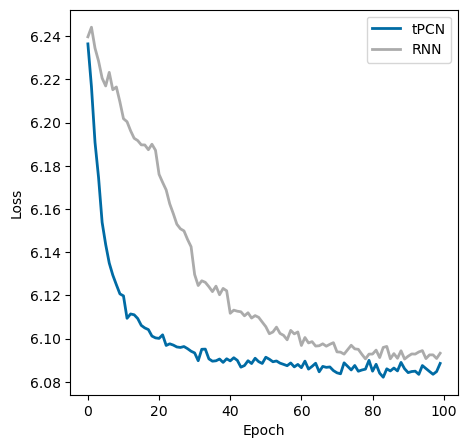

In [33]:
tpc_sparse_path = '../results/tpc/Apr-10-2025-13-18-07'
tpc_path = '../results/tpc/Apr-10-2025-11-08-20'
pcn_path = '../results/pcn/Apr-09-2025-18-40-34'
rnn_path = '../results/rnn/May-03-2025-14-46-21'
rnn_nowd_path = '../results/rnn/Apr-28-2025-10-48-25'
tbptt_path = '../results/rnn/Apr-17-2025-11-07-13'

# pcn_loss = np.load(os.path.join(pcn_path, 'training_loss.npy'))
mpl.style.use('tableau-colorblind10')
tpc_loss = np.load(os.path.join(tpc_path, 'loss.npy'))
tpc_sparse_loss = np.load(os.path.join(tpc_sparse_path, 'loss.npy'))
rnn_loss = np.load(os.path.join(rnn_path, 'loss.npy'))
rnn_nowd_loss = np.load(os.path.join(rnn_nowd_path, 'loss.npy'))

plt.figure(figsize=(5,5))
plt.plot(tpc_loss, label='tPCN', color='C0', lw=2)
# plt.plot(tpc_sparse_loss, label='stPCN', color='C1', lw=2)
plt.plot(rnn_loss, label='RNN', color='C2', lw=2)
# plt.plot(rnn_nowd_loss, label='RNN (more hparams)', color='C4', lw=2)
# plt.plot(tbptt_loss, label='tBPTT', color='C3', lw=2)
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
# plt.tight_layout()
# plt.savefig('../results/abrupt/loss.pdf', bbox_inches='tight')
plt.show()

In [4]:
import numpy as np
from scipy.optimize import curve_fit
from sklearn.cluster import KMeans

# 1. Normalize a curve
def normalize_curve(curve):
    min_val = np.min(curve)
    max_val = np.max(curve)
    return (curve - min_val) / (max_val - min_val + 1e-8)

# 2. Define sigmoid function
def sigmoid(x, L, x0, k, b):
    return L / (1 + np.exp(-k*(x - x0))) + b

# 3. Fit sigmoid to curve
def fit_sigmoid(x, y):
    # Initial guess for parameters: L, x0, k, b
    p0 = [1, np.median(x), 1, 0]
    try:
        popt, _ = curve_fit(sigmoid, x, y, p0, maxfev=10000)
        return popt  # [L, x0, k, b]
    except RuntimeError:
        return None  # Fitting failed


In [5]:
def top_score_evolution(path, filter=False, **kwargs):
    scores = np.array([np.load(os.path.join(path, f'grid_scores/grid_scores_epoch_{i}.npy')) for i in range(2, 102, 2)])
    final_scores = np.load(os.path.join(path, 'grid_scores/grid_scores_epoch_100.npy'))
    idx = np.argsort(final_scores)[::-1]
    scores = scores[:, idx]
    if filter:
        scores = savgol_filter(scores, axis=0, **kwargs)
    return scores

def top_size_by_scale_evolution(path, n_cells=16, env_size=1.6, size_thresh=0.5, scale_method='average'):
    final_scores = np.load(os.path.join(path, 'grid_scores/grid_scores_epoch_100.npy'))
    idx = np.argsort(final_scores)[::-1]
    size_by_scales = np.zeros((51, n_cells))
    for i in tqdm(np.arange(0, 102, 2)):
        sac = np.load(os.path.join(path, f'sacs/sacs_epoch_{i}.npy'))
        sac = sac[idx][:n_cells]
        for c in range(n_cells):
            metrics = compute_grid_metrics(sac[c], env_size, size_thresh, scale_method)
            size = metrics['grid_size_meters']
            scale = metrics['grid_scale_meters']
            size_by_scales[i//2, c] = size / scale 
    return size_by_scales


In [6]:
def extract_popts(path, n_cells=16):
    filter_kwargs = {'window_length': 10, 'polyorder': 2}
    score_evolution = top_score_evolution(path, filter=True, **filter_kwargs)
    score_evolution = score_evolution[:, :n_cells]
    x = np.arange(2, 102, 2)
    popts = {}
    for i in range(n_cells):
        curve = score_evolution[:, i]
        popt = fit_sigmoid(x, curve)
        y_fit = sigmoid(x, *popt)
        if y_fit[0] < y_fit[-1]:
            popts[i] = popt
        else:
            popts[i] = None
    return popts

def get_clusters(popts, path, low=33, high=66):
    x = np.arange(2, 102, 2)
    score_evolution_unfiltered = top_score_evolution(path, filter=False)
    early, middle, late = [], [], []
    for i in range(len(popts)):
        if popts[i] is not None:
            inflection_point = popts[i][1]
            if inflection_point < low:
                early.append(i)
            elif inflection_point > low and inflection_point < high:
                middle.append(i)
            else:
                late.append(i)
    scores_early = score_evolution_unfiltered[:, early]
    scores_middle = score_evolution_unfiltered[:, middle]
    scores_late = score_evolution_unfiltered[:, late]
    return scores_early, scores_middle, scores_late

def plot_clusters(scores_early, scores_middle, scores_late, ax, legend=True, x_label=True, ylabel=True):
    x = np.arange(2, 102, 2)
    mean_early = np.mean(scores_early, axis=1)
    mean_middle = np.mean(scores_middle, axis=1)
    mean_late = np.mean(scores_late, axis=1)

    if np.all(np.isnan(mean_early)) and np.all(np.isnan(mean_middle)) and np.all(np.isnan(mean_late)):
        print("All means are NaN. Nothing to plot.")
        return

    if not np.all(np.isnan(mean_early)):
        early_p = fit_sigmoid(x, mean_early)
        ax.plot(x, mean_early, label='Early', color='gray', linestyle='--', lw=2)
        ax.plot(x, sigmoid(x, *early_p), color='gray', lw=2)
    if not np.all(np.isnan(mean_middle)):
        middle_p = fit_sigmoid(x, mean_middle)
        ax.plot(x, mean_middle, label='Middle', color='k', linestyle='--', lw=2)
        ax.plot(x, sigmoid(x, *middle_p), color='k', lw=2)
    if not np.all(np.isnan(mean_late)):
        late_p = fit_sigmoid(x, mean_late)
        ax.plot(x, mean_late, label='Late', color='r', linestyle='--', lw=2)
        ax.plot(x, sigmoid(x, *late_p), color='r', lw=2)

    if x_label:
        ax.set_xlabel('Epoch')
    if ylabel:
        ax.set_ylabel('Grid score')
    if legend:
        ax.legend(frameon=False, loc='upper left', fontsize=10)

def plot_cells(path, n_cells=16):
    x = np.arange(2, 102, 2)
    filter_kwargs = {'window_length': 10, 'polyorder': 2}
    score_evolution = top_score_evolution(path, filter=True, **filter_kwargs)
    score_evolution = score_evolution[:, :n_cells]
    score_evolution_unfiltered = top_score_evolution(path, filter=False)
    score_evolution_unfiltered = score_evolution_unfiltered[:, :n_cells]

    fig, axes = plt.subplots(2, 8, figsize=(16, 4), sharey=True)
    for i, ax in enumerate(axes.flatten()):
        curve = score_evolution[:, i]
        curve_unfiltered = score_evolution_unfiltered[:, i]
        popt = fit_sigmoid(x, curve)
        y_fit = sigmoid(x, *popt)
        
        ax.plot(x, curve_unfiltered, color='k')
        ax.plot(x, y_fit, color='r')
        ax.set_title(f'Cell {i}')
        if i == 0:
            ax.set_ylabel('Score')
            ax.set_xlabel('Epoch')
        plt.tight_layout()
    plt.show()
                

## Loss

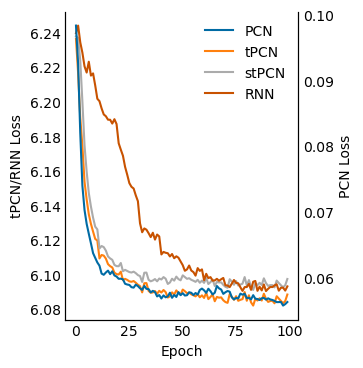

In [7]:
# pcn_loss = np.load(os.path.join(pcn_path, 'training_loss.npy'))
mpl.style.use('tableau-colorblind10')
pcn_loss = np.load(os.path.join(pcn_path, 'training_loss.npy'))
tpc_loss = np.load(os.path.join(tpc_path, 'loss.npy'))
tpc_sparse_loss = np.load(os.path.join(tpc_sparse_path, 'loss.npy'))
rnn_loss = np.load(os.path.join(rnn_path, 'loss.npy'))
tbptt_loss = np.load(os.path.join(tbptt_path, 'loss.npy'))

fig, ax = plt.subplots(figsize=(3,4))
ax.plot([], label='PCN', color='C0', lw=1.5)
ax.plot(tpc_loss, label='tPCN', color='C1', lw=1.5)
ax.plot(tpc_sparse_loss, label='stPCN', color='C2', lw=1.5)
ax.plot(rnn_loss, label='RNN', color='C5', lw=1.5)
ax.set_ylabel('tPCN/RNN Loss')
ax2 = plt.twinx(ax=ax)
ax2.plot(pcn_loss, label='PCN', color='C0', lw=1.5)
ax2.set_ylabel('PCN Loss')

ax.legend(fontsize=10, frameon=False)
# ax2.legend(fontsize=10, frameon=False, loc='upper right')
# plt.plot(tbptt_loss, label='tBPTT', color='C3', lw=2)
# plt.tight_layout()
ax.set_xlabel('Epoch')
ax.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax.tick_params(axis='both', which='both', length=0, labelsize=10)
ax2.tick_params(axis='both', which='both', length=0, labelsize=10)
# plt.tight_layout()
plt.savefig('../results/abrupt/loss.pdf', bbox_inches='tight')
plt.show()

## Size/scales

In [8]:
def select_starting_epoch(path, n_cells=16, quatile=0.75):
    score_evo = top_score_evolution(path)
    score_top_avg_evo = score_evo[:, :n_cells].mean(axis=1)
    # select epoch where the average score is above 75% quantile
    thresh_epoch = np.quantile(score_top_avg_evo, quatile)
    selected_epoch = np.where(score_top_avg_evo > thresh_epoch)[0][0]
    return selected_epoch

In [9]:
def plot_size_by_scale(size_by_scale):
    fig, axes = plt.subplots(2, 8, figsize=(16, 4), sharey=True)
    for i, ax in enumerate(axes.flatten()):
        curve = size_by_scale[:, i]
        ax.plot(np.arange(0, 102, 2), curve, color='k')
        ax.set_title(f'Cell {i}')
        if i == 0:
            ax.set_ylabel('Size / Scale')
            ax.set_xlabel('Epoch')
    plt.tight_layout()

In [10]:
pcn_size_by_scale = top_size_by_scale_evolution(pcn_path, n_cells=16, env_size=1.6, size_thresh=0.5, scale_method='average')
pcn_starting_epoch = select_starting_epoch(pcn_path, n_cells=16, quatile=0.75)

100%|██████████| 51/51 [00:03<00:00, 13.26it/s]


In [11]:
tpc_size_by_scale = top_size_by_scale_evolution(tpc_path, n_cells=16, env_size=1.6, size_thresh=0.5, scale_method='average')
tpc_starting_epoch = select_starting_epoch(tpc_path, n_cells=16, quatile=0.75)

100%|██████████| 51/51 [00:01<00:00, 27.30it/s]


In [12]:
tpc_sparse_size_by_scale = top_size_by_scale_evolution(tpc_sparse_path, n_cells=16, env_size=1.6, size_thresh=0.5, scale_method='average')
tpc_sparse_starting_epoch = select_starting_epoch(tpc_sparse_path, n_cells=16, quatile=0.75)

100%|██████████| 51/51 [00:01<00:00, 26.50it/s]


In [13]:
rnn_size_by_scale = top_size_by_scale_evolution(rnn_path, n_cells=16, env_size=1.6, size_thresh=0.5, scale_method='average')
rnn_starting_epoch = select_starting_epoch(rnn_path, n_cells=16, quatile=0.75)

100%|██████████| 51/51 [00:02<00:00, 25.48it/s]


In [14]:
print(f'PCN starting epoch: {pcn_starting_epoch}')
print(f'tPCN starting epoch: {tpc_starting_epoch}')
print(f'stPCN starting epoch: {tpc_sparse_starting_epoch}')
print(f'RNN starting epoch: {rnn_starting_epoch}')

pcn_size_by_scale = pcn_size_by_scale[pcn_starting_epoch:]
tpc_size_by_scale = tpc_size_by_scale[tpc_starting_epoch:]
tpc_sparse_size_by_scale = tpc_sparse_size_by_scale[tpc_sparse_starting_epoch:]
rnn_size_by_scale = rnn_size_by_scale[rnn_starting_epoch:]

PCN starting epoch: 31
tPCN starting epoch: 23
stPCN starting epoch: 37
RNN starting epoch: 37


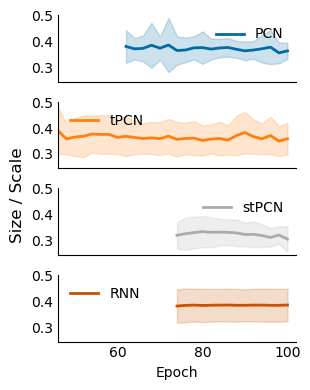

In [15]:
fig, ax = plt.subplots(4, 1, figsize=(3, 4), sharex=True, sharey=True)
ax[0].plot(np.arange(2*pcn_starting_epoch, 102, 2), pcn_size_by_scale.mean(axis=1), label='PCN', color='C0', lw=2)
ax[0].fill_between(
    np.arange(2*pcn_starting_epoch, 102, 2), pcn_size_by_scale.mean(axis=1) - pcn_size_by_scale.std(axis=1),
    pcn_size_by_scale.mean(axis=1) + pcn_size_by_scale.std(axis=1), alpha=0.2, color='C0'
)
ax[1].plot(np.arange(2*tpc_starting_epoch, 102, 2), tpc_size_by_scale.mean(axis=1), label='tPCN', color='C1', lw=2)
ax[1].fill_between(
    np.arange(2*tpc_starting_epoch, 102, 2), tpc_size_by_scale.mean(axis=1) - tpc_size_by_scale.std(axis=1),
    tpc_size_by_scale.mean(axis=1) + tpc_size_by_scale.std(axis=1), alpha=0.2, color='C1'
)
ax[2].plot(np.arange(2*tpc_sparse_starting_epoch, 102, 2), tpc_sparse_size_by_scale.mean(axis=1), label='stPCN', color='C2', lw=2)
ax[2].fill_between(
    np.arange(2*tpc_sparse_starting_epoch, 102, 2), tpc_sparse_size_by_scale.mean(axis=1) - tpc_sparse_size_by_scale.std(axis=1),
    tpc_sparse_size_by_scale.mean(axis=1) + tpc_sparse_size_by_scale.std(axis=1), alpha=0.2, color='C2'
)
ax[3].plot(np.arange(2*rnn_starting_epoch, 102, 2), rnn_size_by_scale.mean(axis=1), label='RNN', color='C5', lw=2)
ax[3].fill_between(
    np.arange(2*rnn_starting_epoch, 102, 2), rnn_size_by_scale.mean(axis=1) - rnn_size_by_scale.std(axis=1),
    rnn_size_by_scale.mean(axis=1) + rnn_size_by_scale.std(axis=1), alpha=0.2, color='C5'
)
ax[3].set_xlabel('Epoch')
# ax[0].set_ylabel('Size / Scale')
# set a sup ylabel for all subplots
fig.text(-0.02, 0.5, 'Size / Scale', va='center', rotation='vertical', fontsize=12)
for a in ax:
    a.legend(frameon=False, fontsize=10)
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.tick_params(axis='both', which='both', length=0, labelsize=10)
    # make all x ticks start from the mininum of the starting epochs
    start = min(pcn_starting_epoch, tpc_starting_epoch, tpc_sparse_starting_epoch, rnn_starting_epoch)
    a.set_xlim(2*start, 102)
plt.tight_layout()
plt.savefig('../results/abrupt/size_by_scale.pdf', bbox_inches='tight')

## Call examples

In [16]:
def get_epoch_rms(path, cell_indices):
    final_scores = np.load(os.path.join(path, 'grid_scores/grid_scores_epoch_100.npy'))
    idx = np.argsort(final_scores)[::-1]

    all_rms = []
    all_scores = []
    for epoch in [0, 34, 66, 100]:
        rms = np.load(os.path.join(path, f'rate_maps_epoch/rate_map_epoch_{epoch}.npy'))
        scores = np.load(os.path.join(path, f'grid_scores/grid_scores_epoch_{epoch}.npy'))
        rms = rms[idx]
        rms = rms[cell_indices]
        scores = scores[idx]
        scores = scores[cell_indices]
        all_rms.append(rms)
        all_scores.append(scores)
    all_rms = np.array(all_rms)
    all_scores = np.array(all_scores)

    return all_rms, all_scores

def get_individual_scores(path, cell_indices):
    final_scores = np.load(os.path.join(path, 'grid_scores/grid_scores_epoch_100.npy'))
    idx = np.argsort(final_scores)[::-1]

    scores = [np.load(os.path.join(path, f'grid_scores/grid_scores_epoch_{e}.npy')) for e in range(0, 102, 2)]
    scores = np.array(scores)
    scores = scores[:, idx]
    scores = scores[:, cell_indices]

    return scores

(4, 2, 30, 30)


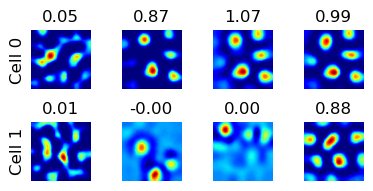

In [17]:
pcn_cells = [6, 10]
pcn_rms, pcn_scores = get_epoch_rms(pcn_path, np.array(pcn_cells))
print(pcn_rms.shape)
fig, ax = plt.subplots(len(pcn_cells), 4, figsize=(4, 2))
for i in range(len(pcn_cells)):
    ax[i, 0].set_ylabel(f'Cell {i}', fontsize=12)
    for j in range(4):
        ax[i, j].imshow(pcn_rms[j, i], cmap='jet', interpolation='bilinear')
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])
        # remove borders
        ax[i, j].spines[['top', 'bottom', 'right', 'left']].set_visible(False)
        ax[i, j].set_title(f'{pcn_scores[j, i]:.2f}')

plt.tight_layout()
plt.savefig('../results/abrupt/pcn_rm.pdf', bbox_inches='tight')
plt.show()


(4, 2, 20, 20)


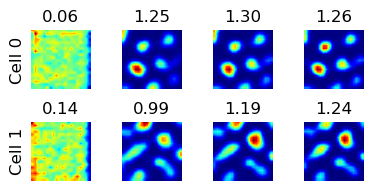

In [18]:
tpc_cells = [0, 1]
tpc_rms, tpc_scores = get_epoch_rms(tpc_path, np.array(tpc_cells))
print(tpc_rms.shape)
fig, ax = plt.subplots(len(tpc_cells), 4, figsize=(4, 2))
for i in range(len(tpc_cells)):
    ax[i, 0].set_ylabel(f'Cell {i}', fontsize=12)
    for j in range(4):
        ax[i, j].imshow(tpc_rms[j, i], cmap='jet', interpolation='bilinear')
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])
        # remove borders
        ax[i, j].spines[['top', 'bottom', 'right', 'left']].set_visible(False)
        ax[i, j].set_title(f'{tpc_scores[j, i]:.2f}')

plt.tight_layout()
plt.savefig('../results/abrupt/tpc_rm.pdf', bbox_inches='tight')
plt.show()

(4, 2, 20, 20)


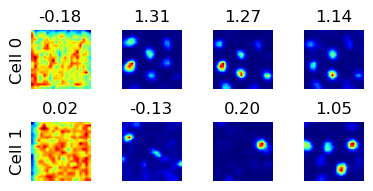

In [19]:
tpc_sparse_cells = [3, 9]
tpc_sparse_rms, tpc_sparse_scores = get_epoch_rms(tpc_sparse_path, np.array(tpc_sparse_cells))
print(tpc_sparse_rms.shape)
fig, ax = plt.subplots(len(tpc_sparse_cells), 4, figsize=(4, 2))
for i in range(len(tpc_sparse_cells)):
    ax[i, 0].set_ylabel(f'Cell {i}', fontsize=12)
    for j in range(4):
        ax[i, j].imshow(tpc_sparse_rms[j, i], cmap='jet', interpolation='bilinear')
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])
        # remove borders
        ax[i, j].spines[['top', 'bottom', 'right', 'left']].set_visible(False)
        ax[i, j].set_title(f'{tpc_sparse_scores[j, i]:.2f}')

plt.tight_layout()
plt.savefig('../results/abrupt/tpc_sparse_rm.pdf', bbox_inches='tight')
plt.show()

(4, 2, 20, 20)


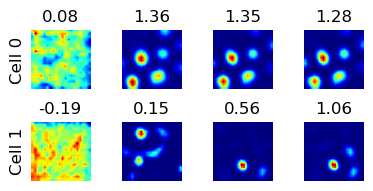

In [30]:
rnn_cells = [3, 15]
rnn_rms, rnn_scores = get_epoch_rms(rnn_path, np.array(rnn_cells))
print(rnn_rms.shape)
fig, ax = plt.subplots(len(rnn_cells), 4, figsize=(4, 2))
for i in range(len(rnn_cells)):
    ax[i, 0].set_ylabel(f'Cell {i}', fontsize=12)
    for j in range(4):
        ax[i, j].imshow(rnn_rms[j, i], cmap='jet', interpolation='bilinear')
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])
        # remove borders
        ax[i, j].spines[['top', 'bottom', 'right', 'left']].set_visible(False)
        ax[i, j].set_title(f'{rnn_scores[j, i]:.2f}')
plt.tight_layout()
plt.savefig('../results/abrupt/rnn_rm.pdf', bbox_inches='tight')
plt.show()

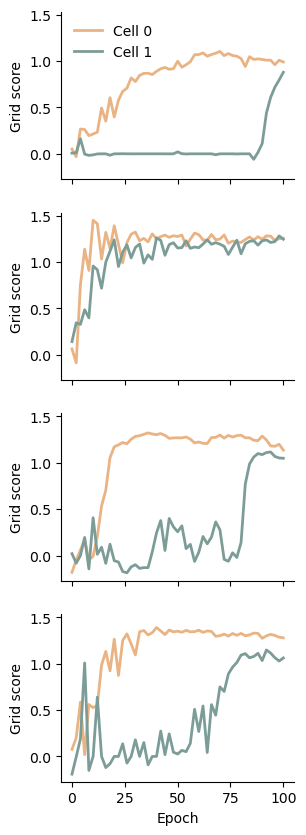

In [32]:
pcn_scores = get_individual_scores(pcn_path, np.array(pcn_cells))
tpc_scores = get_individual_scores(tpc_path, np.array(tpc_cells))
tpc_sparse_scores = get_individual_scores(tpc_sparse_path, np.array(tpc_sparse_cells))
rnn_scores = get_individual_scores(rnn_path, np.array(rnn_cells))

fig, ax = plt.subplots(4, 1, figsize=(3, 10), sharex=True, sharey=True)
# remove top and right spines
ax[0].spines[['top', 'right']].set_visible(False)
ax[0].plot(np.arange(0, 102, 2), pcn_scores[:, 0], label='Cell 0', color="#e9b383", lw=2)
ax[0].plot(np.arange(0, 102, 2), pcn_scores[:, 1], label='Cell 1', color="#7c9d97", lw=2)
ax[0].set_ylabel('Grid score')
ax[0].legend(frameon=False)
ax[0].set_yticks([0, 0.5, 1, 1.5])

ax[1].spines[['top', 'right']].set_visible(False)
ax[1].plot(np.arange(0, 102, 2), tpc_scores[:, 0], label='Cell 0', color="#e9b383", lw=2)
ax[1].plot(np.arange(0, 102, 2), tpc_scores[:, 1], label='Cell 1', color="#7c9d97", lw=2)
ax[1].set_ylabel('Grid score')
# ax[1].legend(frameon=False)

ax[2].spines[['top', 'right']].set_visible(False)
ax[2].plot(np.arange(0, 102, 2), tpc_sparse_scores[:, 0], label='Cell 0', color="#e9b383", lw=2)
ax[2].plot(np.arange(0, 102, 2), tpc_sparse_scores[:, 1], label='Cell 1', color="#7c9d97", lw=2)
ax[2].set_ylabel('Grid score')
# ax[2].legend(frameon=False)

ax[3].spines[['top', 'right']].set_visible(False)
ax[3].plot(np.arange(0, 102, 2), rnn_scores[:, 0], label='Cell 0', color="#e9b383", lw=2)
ax[3].plot(np.arange(0, 102, 2), rnn_scores[:, 1], label='Cell 1', color="#7c9d97", lw=2)
ax[3].set_xlabel('Epoch')
ax[3].set_ylabel('Grid score')
# ax[3].legend(frameon=False)

# plt.tight_layout()
plt.savefig('../results/abrupt/individual.pdf', bbox_inches='tight')
plt.show()


## Scores

C:\Users\User\AppData\Local\Temp\ipykernel_1968\2519742339.py:13: RuntimeWarning: overflow encountered in exp
  return L / (1 + np.exp(-k*(x - x0))) + b


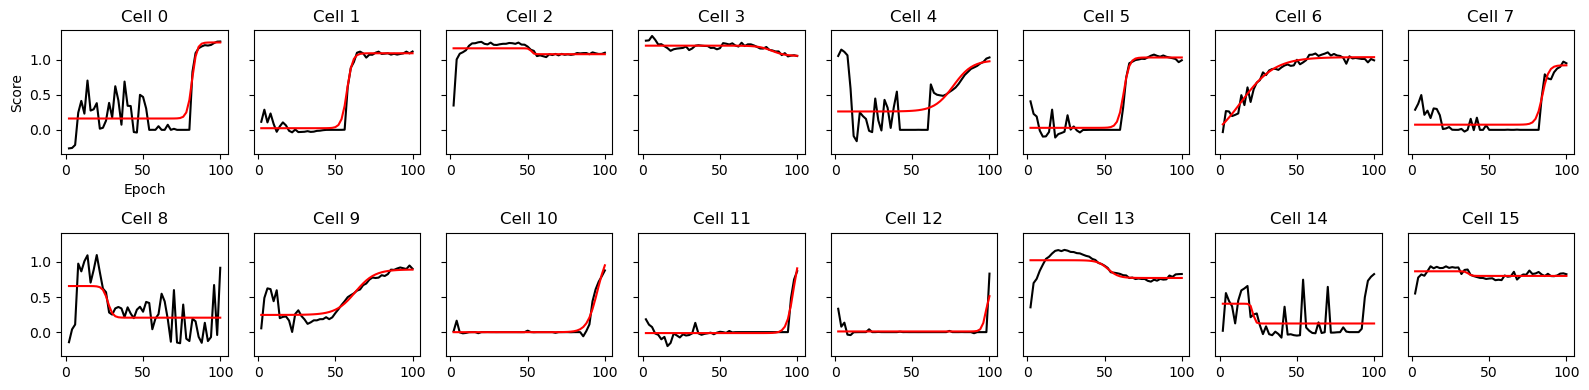

In [22]:
pcn_popts = extract_popts(pcn_path, n_cells=16)
plot_cells(pcn_path, n_cells=16)

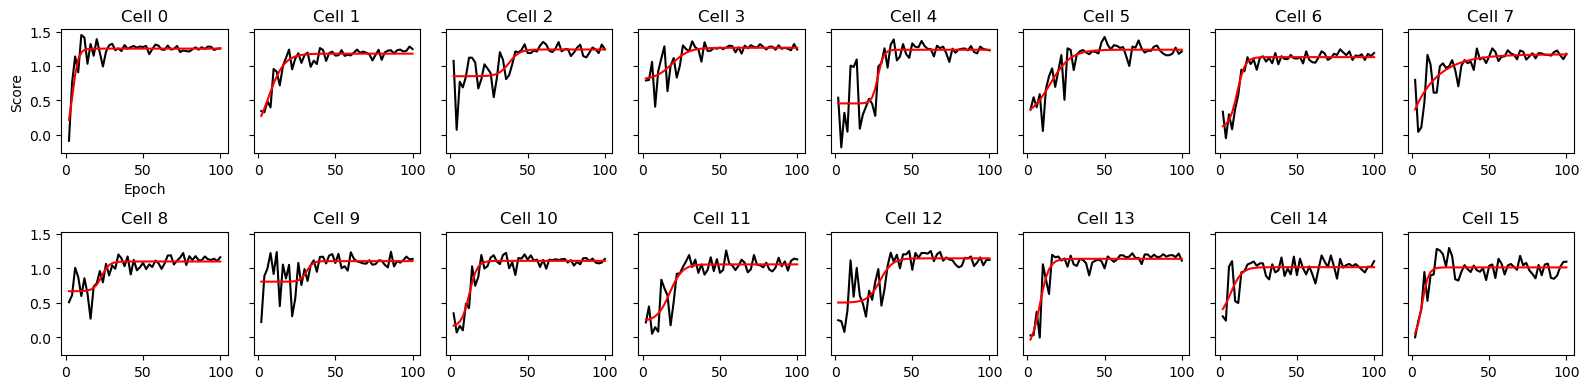

In [23]:
tpc_popts = extract_popts(tpc_path, n_cells=16)
plot_cells(tpc_path, n_cells=16)

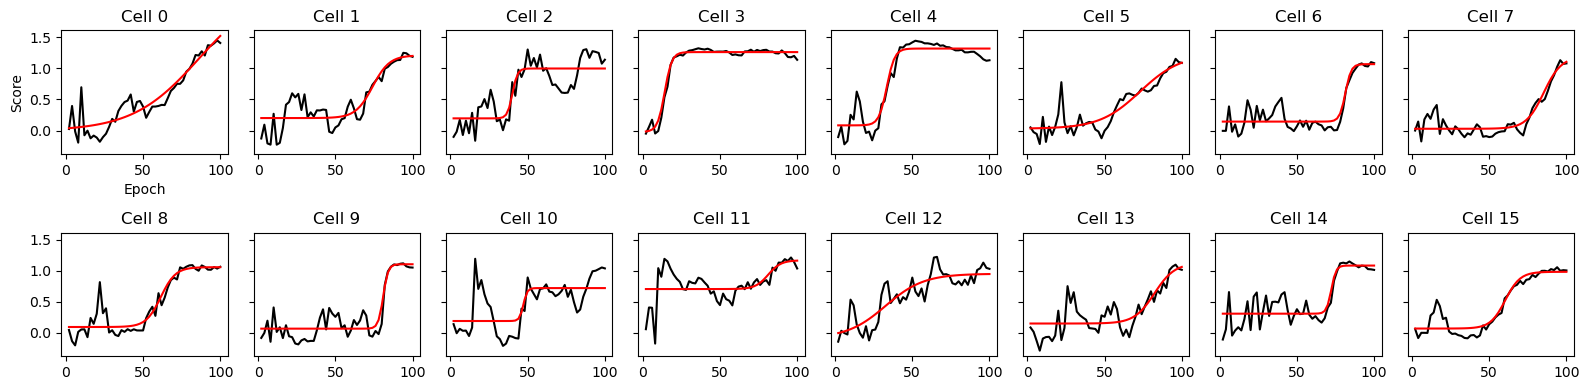

In [24]:
tpc_sparse_popts = extract_popts(tpc_sparse_path, n_cells=16)
plot_cells(tpc_sparse_path, n_cells=16)

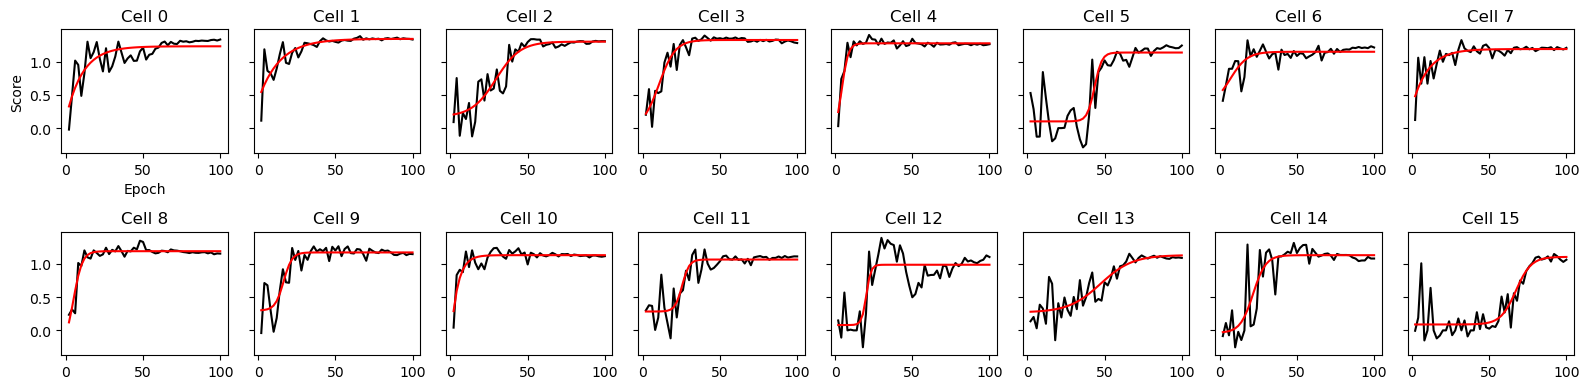

In [25]:
rnn_popts = extract_popts(rnn_path, n_cells=16)
plot_cells(rnn_path, n_cells=16)

## Clusters

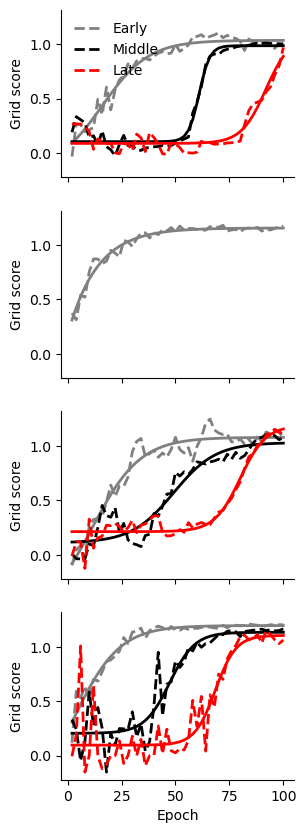

In [27]:
fig, ax = plt.subplots(4, 1, figsize=(3, 10), sharex=True, sharey=True)
for a in ax:
    a.spines[['top', 'right']].set_visible(False)
plot_clusters(*get_clusters(pcn_popts, pcn_path), ax=ax[0], legend=True, x_label=False, ylabel=True)
plot_clusters(*get_clusters(tpc_popts, tpc_path, low=40, high=66), ax=ax[1], legend=False, x_label=False, ylabel=True)
plot_clusters(*get_clusters(tpc_sparse_popts, tpc_sparse_path), ax=ax[2], legend=False, x_label=False, ylabel=True)
plot_clusters(*get_clusters(rnn_popts, rnn_path), ax=ax[3], legend=False, x_label=True, ylabel=True)
plt.savefig('../results/abrupt/clusters.pdf', bbox_inches='tight')
plt.show()